# Exercise 3 — Image Classification (Pretrained Models)
### Bean Leaf Disease Detector

---

## The Problem

An agricultural AI startup is building a mobile app that lets farmers
photograph their bean crops and instantly detect disease.
The app must distinguish between three conditions:
**angular leaf spot**, **bean rust**, and **healthy**.

The dataset is small — a few hundred images per class.
Training a CNN from scratch will not work here.
Your job is to use transfer learning to build something that actually performs.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")
```

The dataset comes with a `train.csv` and a `val.csv`.
Each has an `image:FILE` column with relative paths and a `category` column with the label.

⚠️ **One thing worth knowing:** the file paths in the CSV are relative.
You will need to prepend the correct Colab base path to make them readable.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A fine-tuned pretrained model** from `torchvision.models` that classifies bean leaf conditions
2. **A clear statement** of which model you chose and which layers you froze or unfroze — and why
3. **A training report** — loss and accuracy curves over epochs
4. **A test accuracy score**
5. **A live inference demo** — given a leaf image, the model returns the diagnosis

You must use a pretrained model from `torchvision.models`.
The choice of which model is yours — be ready to justify it.

---

In [1]:
!git clone https://github.com/Ibraheem-Al-hafith/classification_hub.git
%cd classification_hub

/content/classification_hub


In [2]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    print(f"Random seed set to: {seed}")

class config:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size = 32 # This batch_size is not directly used by dataloader_configs
    num_workers = 2
    learning_rate = 0.001
    num_epochs = 2
    dataset_name = "marquis03/bean-leaf-lesions-classification"
    h, w = 384, 384
    scaler = "standard" # options: "standard" , "minmax" , "robust"
    dataloader_configs = {
        "batch_size": 32, # Reduced batch size to mitigate OutOfMemoryError
        "num_workers": 2,
        "pin_memory": True
    }

seed_everything(config.seed)
print(f"Device set to: {config.device}")

Random seed set to: 42
Device set to: cuda


In [3]:
from utilities import download_kaggle_dataset
images_path = download_kaggle_dataset(config.dataset_name)

Using Colab cache for faster access to the 'bean-leaf-lesions-classification' dataset.
Path to the dataset: /kaggle/input/bean-leaf-lesions-classification
Is the path a file? False
Files inside the path: ['val.csv', 'classname.txt', 'val', 'train.csv', 'train']


In [4]:
import pandas as pd
train_df = pd.read_csv(Path(images_path) / "train.csv").rename(columns={"image:FILE":"image_path", "category":"label"})
val_df = pd.read_csv(Path(images_path) / "val.csv").rename(columns={"image:FILE":"image_path", "category":"label"})

train_df.image_path = train_df.image_path.apply(lambda path: Path(images_path) / path)
val_df.image_path = val_df.image_path.apply(lambda path: Path(images_path) / path)
train_df.head()

,image_path,label
0,/kaggle/input/bean-leaf-lesions-classification...,0
1,/kaggle/input/bean-leaf-lesions-classification...,0
2,/kaggle/input/bean-leaf-lesions-classification...,0
3,/kaggle/input/bean-leaf-lesions-classification...,0
4,/kaggle/input/bean-leaf-lesions-classification...,0


In [5]:
train_df, test_df = train_test_split(train_df, test_size=0.1, random_state=config.seed, stratify=train_df.label)

In [6]:
display(
    "Train: ",train_df.groupby("label").count(),
    "Val: ",val_df.groupby("label").count(),
    "Test: ",test_df.groupby("label").count()
)

'Train: '

,image_path
label,
0,307
1,310
2,313


'Val: '

,image_path
label,
0,44
1,44
2,45


'Test: '

,image_path
label,
0,34
1,35
2,35


In [7]:
"""Dataset utility module for processing image classification from a pandas DataFrame metadata file.

This module provides a robust PyTorch Dataset that parses images based on paths and labels
supplied within a pandas DataFrame. It handles missing or corrupted files gracefully
during training and provides batch visualization functions.
"""

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision.io import ImageReadMode, read_image
from torchvision.transforms import v2

# Setup basic logging for tracking corrupted files
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("ImageDataset")


class ImageMetaDataset(Dataset):
    """A robust PyTorch Dataset that processes images using a pandas DataFrame metadata source."""

    def __init__(
        self,
        df: pd.DataFrame,
        transform: Optional[v2.Transform] = None,
        config: config = config(),
    ) -> None:
        """Initializes the dataset with a metadata dataframe and builds class maps.

        Args:
            df: pandas DataFrame containing 'image_path' and 'label' columns.
            transform: Optional torchvision v2 transforms.
            config: config instance providing target h and w parameters.

        Raises:
            ValueError: If required columns are missing, or if the DataFrame is empty.
        """
        # Validate critical requirements
        if df.empty:
            raise ValueError("CRITICAL ERROR: Provided pandas DataFrame metadata is empty.")

        required_cols = {"image_path", "label"}
        if not required_cols.issubset(df.columns):
            raise ValueError(f"CRITICAL ERROR: DataFrame must contain columns: {required_cols}")

        self.df = df.reset_index(drop=True)
        self.config = config

        # Determine class structures dynamically
        # Casts downstream slices to strings to support both uniform text and encoded data layouts
        unique_labels = sorted(list(self.df["label"].unique().astype(str)))
        self.classes = unique_labels
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}

        # Assign transform property with a fallback default pipeline
        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize((self.config.h, self.config.w)),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self) -> int:
        """Returns the total number of records within the metadata dataframe."""
        return len(self.df)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Fetches, processes, and returns a specific (image, label) pair by row index.

        If a non-critical error occurs (e.g. corrupted file), it logs a warning
        and returns a zero-tensor placeholder to prevent training loop failures.
        """
        row = self.df.iloc[index]
        img_path_raw = row["image_path"]
        img_path = Path(img_path_raw)

        try:
            # Resolve raw categorical value to standard indexing labels
            raw_label = str(row["label"])
            label_idx = self.class_to_idx[raw_label]
            label_tensor = torch.tensor(label_idx, dtype=torch.long)

            # Read image natively into an RGB torch tensor
            image = read_image(str(img_path), mode=ImageReadMode.RGB)

            # Apply defined or fallback transforms
            if self.transform:
                image = self.transform(image)

            return image, label_tensor

        except Exception as e:
            # Non-critical error handling: Catch file corruptions gracefully
            logger.warning(
                f"Skipping corrupted/unreadable image index {index}: '{img_path}'. "
                f"Reason: {e}. Returning zero tensor placeholder."
            )

            # Generate a clean zero-filled tensor matching expected configuration
            zero_image = torch.zeros((3, self.config.h, self.config.w), dtype=torch.float32)
            dummy_label = torch.tensor(-1, dtype=torch.long)

            return zero_image, dummy_label

    def plot_images(
        self,
        paths_list: Optional[List[Union[str, Path]]] = None,
        targets_list: Optional[List[int]] = None,
        num_images: int = 4,
    ) -> None:
        """Plots a grid of images alongside their metadata label descriptors."""
        fig_images: List[torch.Tensor] = []
        fig_titles: List[str] = []

        if paths_list is not None:
            limit = min(len(paths_list), num_images)
            for i in range(limit):
                try:
                    p = Path(paths_list[i])
                    img = read_image(str(p), mode=ImageReadMode.RGB)
                    img = v2.functional.resize(img, (self.config.h, self.config.w))

                    if targets_list is not None and i < len(targets_list):
                        idx = targets_list[i]
                        title = self.classes[idx] if 0 <= idx < len(self.classes) else f"Class ID: {idx}"
                    else:
                        title = p.parent.name

                    fig_images.append(img)
                    fig_titles.append(title)
                except Exception as e:
                    logger.error(f"Cannot plot custom path element: '{paths_list[i]}'. Error: {e}")
        else:
            limit = min(len(self), num_images)
            for i in range(limit):
                img, label_tensor = self.__getitem__(np.random.randint(0, len(self)))
                label_idx = label_tensor.item()

                if label_idx == -1:
                    title = "Corrupted File Placeholder"
                else:
                    title = self.classes[label_idx]

                if img.max() != 0:
                    img = (img - img.min()) / (img.max() - img.min())

                fig_images.append(img)
                fig_titles.append(title)

        if not fig_images:
            print("No valid images available to render.")
            return

        cols = min(4, len(fig_images))
        rows = (len(fig_images) + cols - 1) // cols
        fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

        if len(fig_images) == 1:
            axs = [axs]
        else:
            axs = axs.flatten() if hasattr(axs, "flatten") else axs

        for idx, (img, title) in enumerate(zip(fig_images, fig_titles)):
            if isinstance(img, torch.Tensor):
                img_np = img.permute(1, 2, 0).cpu().numpy()
            else:
                img_np = img

            axs[idx].imshow(img_np)
            axs[idx].set_title(title)
            axs[idx].axis("off")

        for j in range(len(fig_images), len(axs)):
            axs[j].axis("off")

        plt.tight_layout()
        plt.show()

# Modelling:

In [8]:
import torch
import torchvision.models as models

# Load with the latest default pretrained weights (ImageNet-1K)
weights = models.MobileNet_V3_Small_Weights.DEFAULT


In [9]:
# 1. prepare the dataloader
train_ds = ImageMetaDataset(train_df, transform=weights.transforms())
val_ds = ImageMetaDataset(val_df, transform=weights.transforms())
test_ds = ImageMetaDataset(test_df, transform=weights.transforms())

train_loader = DataLoader(train_ds, shuffle=True, **config.dataloader_configs)
val_loader = DataLoader(val_ds, shuffle=False, **config.dataloader_configs)
test_loader = DataLoader(test_ds, shuffle=False, **config.dataloader_configs)
# 2. prepare the criterion and model
criterion = nn.CrossEntropyLoss()

model = models.mobilenet_v3_small(weights=weights, ).to(config.device)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 3)
# 3. prepare the optimizer
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

In [10]:
# 3. importing the trainer
from utilities import Trainer, TrainerConfig

config=TrainerConfig()
config.task_type="multi"
trainer = Trainer(
    model=model,
    config=config,
    criterion=criterion, train_loader=train_loader,
    val_loader=val_loader
    )

#trainer.fit()

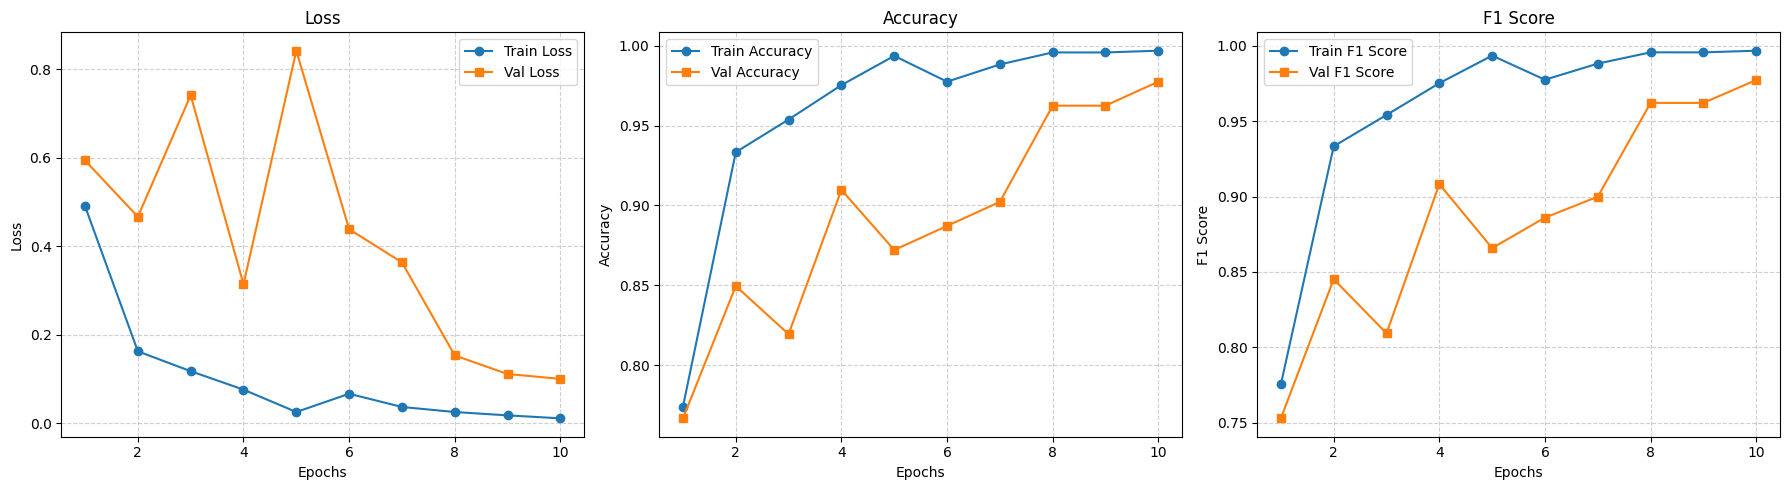

In [11]:
trainer.plot_metrics()

In [15]:
trainer.evaluate(test_loader)

(0.2735227094246791, 0.9423076923076923, 0.9422657952069717)

In [11]:
!pip install ultralytics -q

In [18]:
import time
import gc
import psutil
import torch
import pandas as pd
import numpy as np
import timm
import torchvision.models as models
from utilities import Trainer, TrainerConfig
from ultralytics import YOLO


# Ensure psutil records CPU baseline properly
psutil.cpu_percent(interval=None)

def measure_inference_latency(model, device, num_warmup=20, num_iters=100):
    """Measures precise single-image inference latency on the hardware device."""
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224, device=device)

    # 1. Warm up the GPU/CPU execution queues (caches kernels, handles scaling)
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    # 2. Benchmark execution loop
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_iters):
            _ = model(dummy_input)
            if device.type == "cuda":
                torch.cuda.synchronize(device)

    end_time = time.perf_counter()
    avg_latency_ms = ((end_time - start_time) / num_iters) * 1000
    return avg_latency_ms

# Define experimental configurations matching your existing trainer structures
num_classes = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results_records = []

# Dictionary holding model-loading factory definitions
model_factories = {
    "YOLOv8-cls": lambda: YOLO("yolov8n-cls.pt").model.model,
    "MobileNetV3-Small": lambda: models.mobilenet_v3_small(weights="DEFAULT"),
    "EfficientNet-Lite0": lambda: timm.create_model("efficientnet_lite0", pretrained=True),
    "DINOv2 (ViT-S/14)": lambda: timm.create_model("vit_small_patch14_reg4_dinov2", pretrained=True, num_classes=num_classes)
}

# Run loop over each architecture sequentially to avoid cross-contamination of memory
for model_name, factory_fn in model_factories.items():
    print(f"\n{'='*50}\nProfiling Architecture: {model_name}\n{'='*50}")

    # Clean baseline state entirely before building the architecture
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    # 1. Instantiate model and systematically rewrite its classifier head
    model = factory_fn()

    if model_name == "MobileNetV3-Small":
        in_features = model.classifier[3].in_features
        model.classifier[3] = torch.nn.Linear(in_features, num_classes)
    elif model_name == "EfficientNet-Lite0":
        in_features = model.classifier.in_features
        model.classifier = torch.nn.Linear(in_features, num_classes)
    elif model_name == "YOLOv8-cls":
        in_features = model[-1].linear.in_features
        model[-1].linear = torch.nn.Linear(in_features, num_classes)
    elif model_name == "DINOv2 (ViT-S/14)":
        in_features = model.head.in_features
        model.head = torch.nn.Linear(in_features, num_classes)

    model = model.to(device)

    # 2. Configure a standard generic config instance for training
    config = TrainerConfig(
        device=str(device),
        epochs=5,  # Kept short for quick matrix validation; change to your standard target as needed
        batch_size=32,
        task_type="multiclass"
    )

    criterion = torch.nn.CrossEntropyLoss()
    trainer = Trainer(
        model=model,
        config=config,
        criterion=criterion,
        train_loader=train_loader,  # Pulls from your notebook's existing dataloaders
        val_loader=val_loader
    )

    # Reset peak memory records right before the loops spin up
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    # 3. Profile training run execution metrics
    start_train_time = time.time()
    history = trainer.fit()
    total_train_time_sec = time.time() - start_train_time

    # Collect tracking indicators post-execution
    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
    system_ram_gb = psutil.virtual_memory().used / (1024 ** 3)
    avg_cpu_percent = psutil.cpu_percent(interval=None)

    # 4. Profile precise inference latency using standalone loop
    inference_latency_ms = measure_inference_latency(model, device)

    # 5. Extract best evaluation metrics recorded during training history logs
    best_acc = max(history["val_acc"]) * 100 if history["val_acc"] else 0.0
    best_f1 = max(history["val_f1"]) if history["val_f1"] else 0.0

    # Commit variables to tracking collection records
    results_records.append({
        "Model Architecture": model_name,
        "Peak VRAM (MB)": round(peak_vram_mb, 2),
        "Peak Sys RAM (GB)": round(system_ram_gb, 2),
        "Avg CPU Usage (%)": round(avg_cpu_percent, 1),
        "Total Train Time (s)": round(total_train_time_sec, 2),
        "Single-Image Latency (ms)": round(inference_latency_ms, 3),
        "Best Val Accuracy (%)": round(best_acc, 2),
        "Best Val F1 Score": round(best_f1, 4)
    })

    # 6. Evacuate memory elements completely before next iteration step
    del model, trainer, criterion, config, history
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Generate and print the comprehensive performance evaluation matrix
df_comparison = pd.DataFrame(results_records)
print("\n" + "="*80 + "\nFINAL CRITERIA EXPERIMENTAL TRACKING SUMMARY\n" + "="*80)
display(df_comparison)


FINAL CRITERIA EXPERIMENTAL TRACKING SUMMARY


,Model Architecture,Peak VRAM (MB),Peak Sys RAM (GB),Avg CPU Usage (%),Total Train Time (s),Single-Image Latency (ms),Best Val Accuracy (%),Best Val F1 Score
0,YOLOv8-cls,168.34,2.32,93.2,53.56,5.119,91.73,0.9165
1,MobileNetV3-Small,596.82,2.42,93.0,46.91,6.073,93.98,0.9398
2,EfficientNet-Lite0,2594.09,2.40,91.0,54.25,5.499,99.25,0.9925


In [19]:
import time
import gc
import psutil
import torch
import pandas as pd
import numpy as np
import timm
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from utilities import Trainer, TrainerConfig
from ultralytics import YOLO

# Ensure psutil records CPU baseline properly
psutil.cpu_percent(interval=None)

def measure_inference_latency(model, device, num_warmup=20, num_iters=100):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224, device=device)
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(dummy_input)
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_iters):
            _ = model(dummy_input)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
    end_time = time.perf_counter()
    return ((end_time - start_time) / num_iters) * 1000

num_classes = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results_records = []

model_factories = {
    "YOLOv8-cls": lambda: YOLO("yolov8n-cls.pt").model.model,
    "MobileNetV3-Small": lambda: models.mobilenet_v3_small(weights="DEFAULT"),
    "EfficientNet-Lite0": lambda: timm.create_model("efficientnet_lite0", pretrained=True),
    "DINOv2 (ViT-S/14)": lambda: timm.create_model("vit_small_patch14_reg4_dinov2", pretrained=True, num_classes=num_classes)
}

for model_name, factory_fn in model_factories.items():
    print(f"\nProfiling Architecture: {model_name}")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    model = factory_fn()
    model_transforms = None

    if model_name == "MobileNetV3-Small":
        in_features = model.classifier[3].in_features
        model.classifier[3] = torch.nn.Linear(in_features, num_classes)
        model_transforms = models.MobileNet_V3_Small_Weights.DEFAULT.transforms()
    elif model_name == "EfficientNet-Lite0":
        in_features = model.classifier.in_features
        model.classifier = torch.nn.Linear(in_features, num_classes)
        data_config = timm.data.resolve_model_data_config(model)
        model_transforms = timm.data.create_transform(**data_config, is_training=False)
    elif model_name == "YOLOv8-cls":
        in_features = model[-1].linear.in_features
        model[-1].linear = torch.nn.Linear(in_features, num_classes)
        # FIX: Manual transform for YOLOv8 instead of calling timm
        model_transforms = v2.Compose([v2.Resize((224, 224)), v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    elif model_name == "DINOv2 (ViT-S/14)":
        in_features = model.head.in_features
        model.head = torch.nn.Linear(in_features, num_classes)
        data_config = timm.data.resolve_model_data_config(model)
        model_transforms = timm.data.create_transform(**data_config, is_training=False)

    model = model.to(device)
    # Use a dummy config_ds or existing config object if defined earlier
    ds_config = type('obj', (object,), {'h': 224, 'w': 224})
    current_train_dataset = ImageMetaDataset(df=train_df, transform=model_transforms, config=ds_config)
    current_val_dataset = ImageMetaDataset(df=val_df, transform=model_transforms, config=ds_config)
    current_train_loader = DataLoader(current_train_dataset, batch_size=32, shuffle=True, num_workers=2)
    current_val_loader = DataLoader(current_val_dataset, batch_size=32, shuffle=False, num_workers=2)

    trainer_cfg = TrainerConfig(device=str(device), epochs=5, batch_size=32, task_type="multiclass")
    criterion = torch.nn.CrossEntropyLoss()
    trainer = Trainer(model=model, config=trainer_cfg, criterion=criterion, train_loader=current_train_loader, val_loader=current_val_loader)

    start_train_time = time.time()
    history = trainer.fit()
    total_train_time_sec = time.time() - start_train_time

    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
    inference_latency_ms = measure_inference_latency(model, device)

    results_records.append({
        "Model Architecture": model_name,
        "Peak VRAM (MB)": round(peak_vram_mb, 2),
        "Total Train Time (s)": round(total_train_time_sec, 2),
        "Single-Image Latency (ms)": round(inference_latency_ms, 3),
        "Best Val F1 Score": round(max(history["val_f1"]), 4) if history["val_f1"] else 0.0
    })

    del model, trainer, current_train_loader, current_val_loader
    gc.collect()

df_comparison = pd.DataFrame(results_records)
display(df_comparison)


Profiling Architecture: YOLOv8-cls


RuntimeError: Unknown model (yolov8n_cls)

In [16]:
import timm
import torch.nn as nn

# 1. Load the DINOv2 model and specify num_classes=3 to automatically create the head
# num_classes=3 matches Angular Leaf Spot, Bean Rust, and Healthy
model =

# 2. Move to device
model = model.to(config.device)

print(f"DINOv2 initialized with classification head for {model.num_classes} classes.")
display(model.head)

NameError: name 'config' is not defined